In [8]:
%reload_ext autoreload
%autoreload 2

from utils.custom_sounds import Tone, WhiteNoise, Click, Click_Train
import brian2 as b2
import brian2hears as b2h
from analyze.report import plot_sound
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import fftconvolve, resample
import os
import pysofaconventions as sofa
from scipy.fft import rfft, irfft


## HRTF - ITD ONLY - ILD ONLY

Original sound level: 58.63 dB


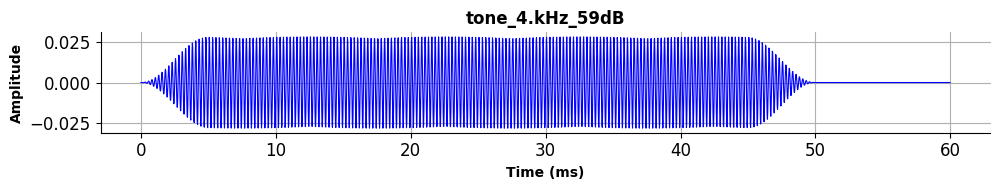

In [9]:
TIME_SIMULATION = 60
level = 60 * b2h.dB
sound = Tone(4 * b2.kHz, duration=50 * b2.ms, level=60 * b2h.dB, ramp_ms=5, offset_silence_duration= 10 * b2.ms)
plot_sound(sound, figsize=(10, 2))
print(f"Original sound level: {sound.sound.level:.2f} dB")

In [10]:
sound.sound.play()

In [11]:
print(sound.sound.level)
#check
sound_array = sound.sound.__array__()
# p_peak = np.max(sound_array)
# p_rms = p_peak/np.sqrt(2)
# ms_dB = 20.0 * np.log10(p_rms / 2e-5)
np.mean(sound_array**2)
rms_value = np.sqrt(np.mean(sound_array**2))
ms_dB = 20.0*np.log10(rms_value/2e-5)
print(f"RMS dB SPL: {ms_dB}")

58.627423877990346*dB
RMS dB SPL: 58.62742387799037


In [12]:
from utils.hrtf_utils import load_hrtf_subject, apply_sofa_hrtf_to_sound, load_hrir, plot_hrir, plot_hrtf_magnitude
from utils.cochlea_utils import ANGLE_TO_SOFA

In [13]:
subject = 0
angle = 90
sofa_file = load_hrtf_subject(subject)
left_ir, right_ir, sofa_fs = load_hrir(subject, ANGLE_TO_SOFA[angle])


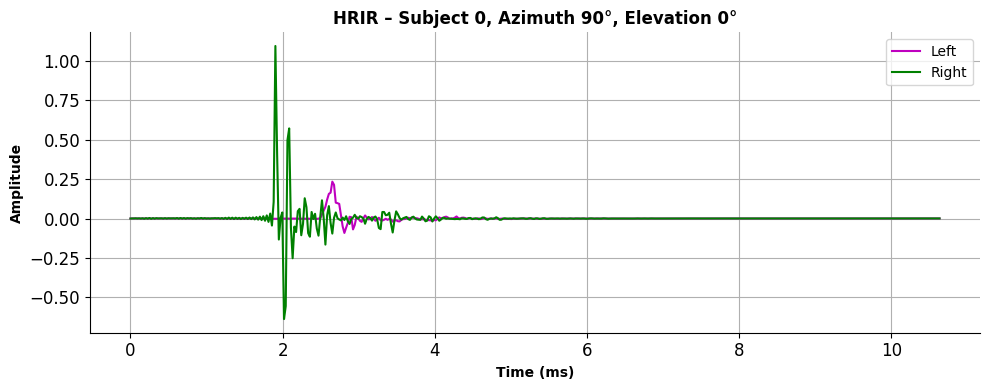

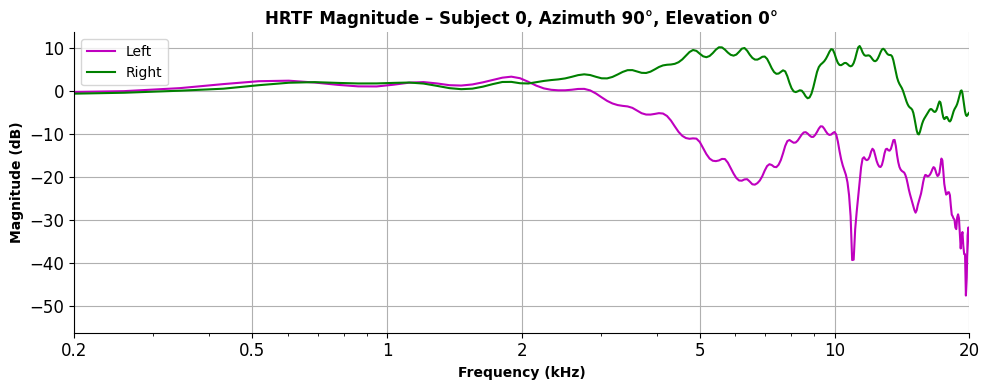

In [14]:
from brian2 import Hz
sound_fs = sound.sound.samplerate/Hz
plot_hrir(subject, ANGLE_TO_SOFA[angle], sound_fs)
plot_hrtf_magnitude(subject, ANGLE_TO_SOFA[angle], sound_fs)

In [15]:
from utils.hrtf_utils import estimate_itd_from_hrir, apply_itd_to_sound, apply_ild_to_sound

Left level after HRTF: 53.40503280125826*dB
Right level after HRTF: 63.954150513649765*dB
Computed ILD: -10.55 dB


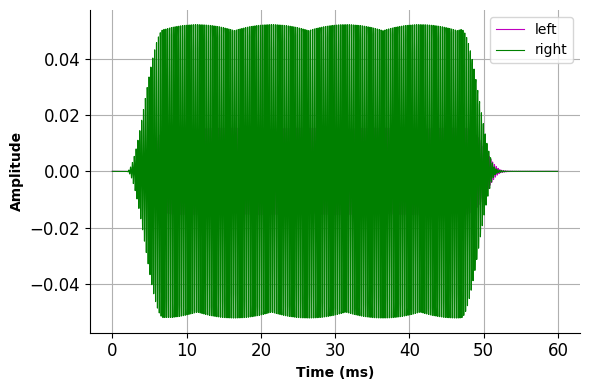

In [16]:
bi_sound = apply_sofa_hrtf_to_sound(sofa_file, sound.sound, ANGLE_TO_SOFA[angle])
plot_sound(bi_sound)
left_level = bi_sound[:,0].level
print("Left level after HRTF:", left_level)
right_level = bi_sound[:,1].level
print("Right level after HRTF:", right_level)
computed_ild = left_level - right_level
print(f"Computed ILD: {computed_ild:.2f} dB")

Extracted ITD: 839.0022675736961 us
Left level after ITD only: 58.62742388808505*dB
Right level after ITD only: 58.62742388808505*dB
Computed ILD: 0.00 dB


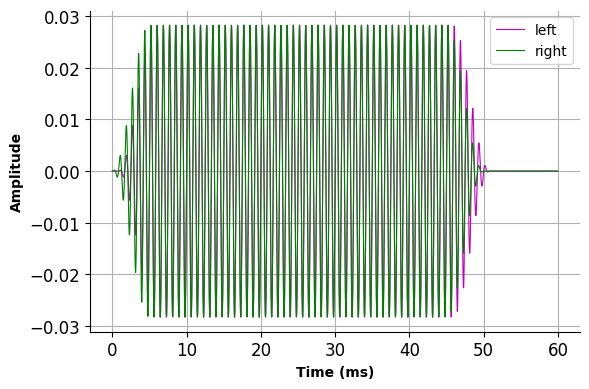

In [11]:
itd = estimate_itd_from_hrir(left_ir,right_ir,sound_fs)
print("Extracted ITD:", itd*1000000, 'us')
bi_sound_itd = apply_itd_to_sound(sound.sound, itd)
plot_sound(bi_sound_itd)
left_level = bi_sound_itd[:,0].level
print("Left level after ITD only:", left_level)
right_level = bi_sound_itd[:,1].level
print("Right level after ITD only:", right_level)
computed_ild = left_level - right_level
print(f"Computed ILD: {computed_ild:.2f} dB")

Left level after ILD only: 60.73891839643874*dB
Right level after ILD only: 60.424440080033825*dB
Computed ILD: 0.31 dB


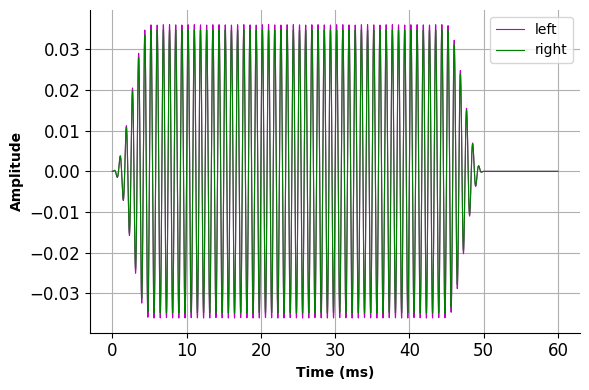

In [12]:
bi_sound_ild = apply_ild_to_sound(sofa_file, sound.sound, ANGLE_TO_SOFA[angle])
plot_sound(bi_sound_ild)
left_level = bi_sound_ild[:,0].level
print("Left level after ILD only:", left_level)
right_level = bi_sound_ild[:,1].level
print("Right level after ILD only:", right_level)
computed_ild = left_level - right_level
print(f"Computed ILD: {computed_ild:.2f} dB")

## INSIDE THE HRTF FUNCTION

WARNING    /var/folders/ll/11knr8bs6_nbxy20yw3f5kfh0000gn/T/ipykernel_26855/4090975755.py:107: UserWarning:Attempt to set non-positive xlim on a log-scaled axis will be ignored.
 [py.warnings]


len hrir before resample: 512
sound_fs 44100.0
hrir_fs 48000.0
len hrir after resample: 470
Left ear sound level (dB SPL): 53.40503280125826*dB
Right ear sound level (dB SPL): 63.954150513649765*dB


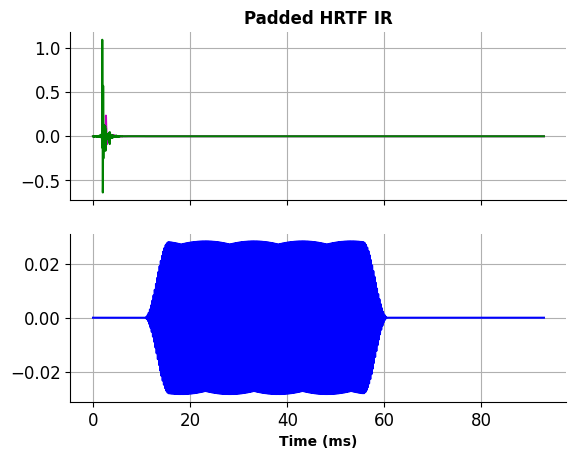

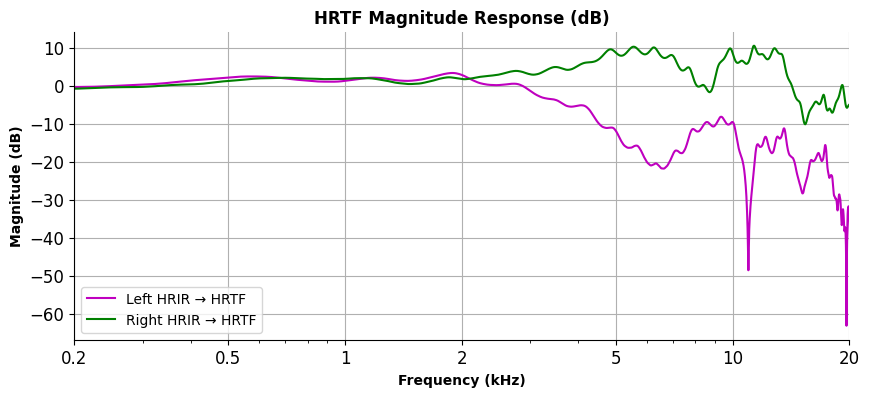

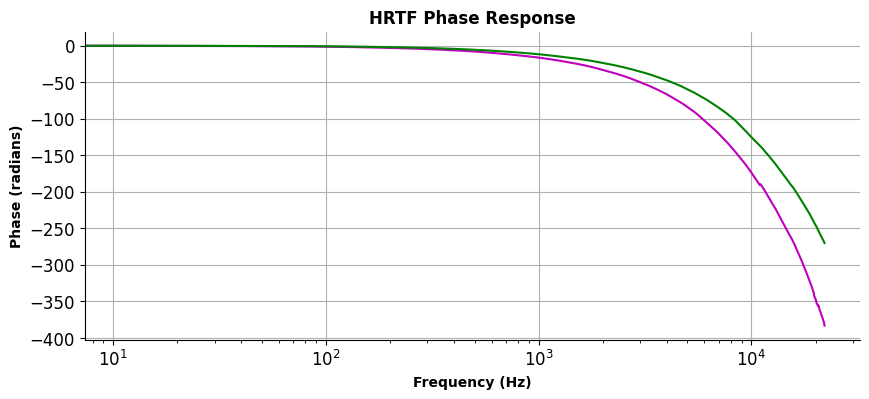

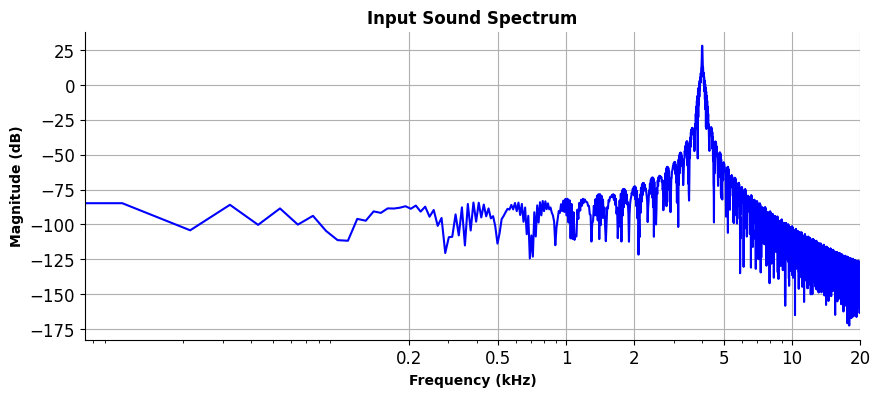

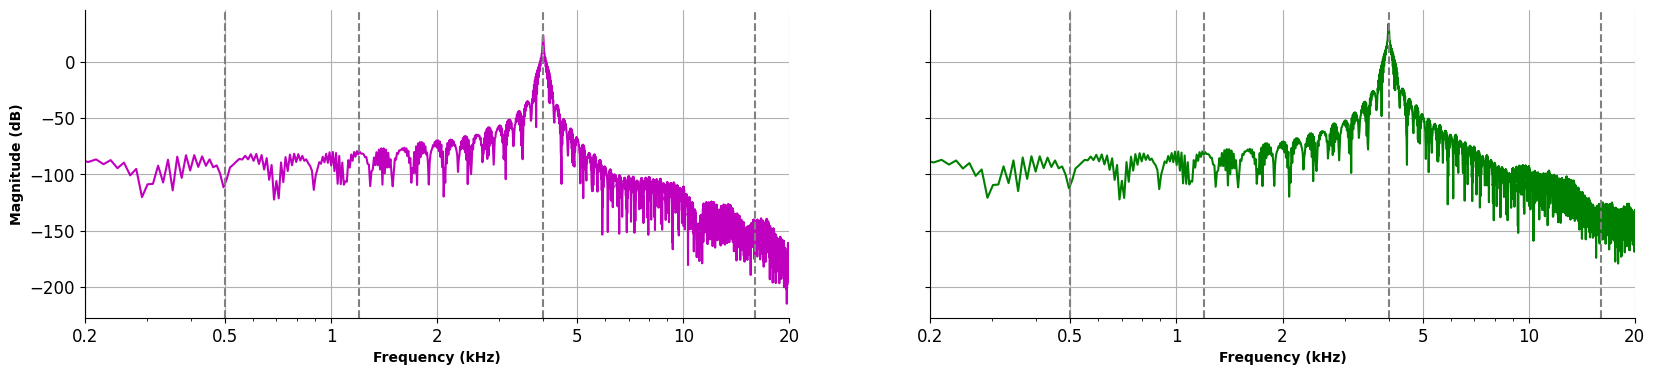

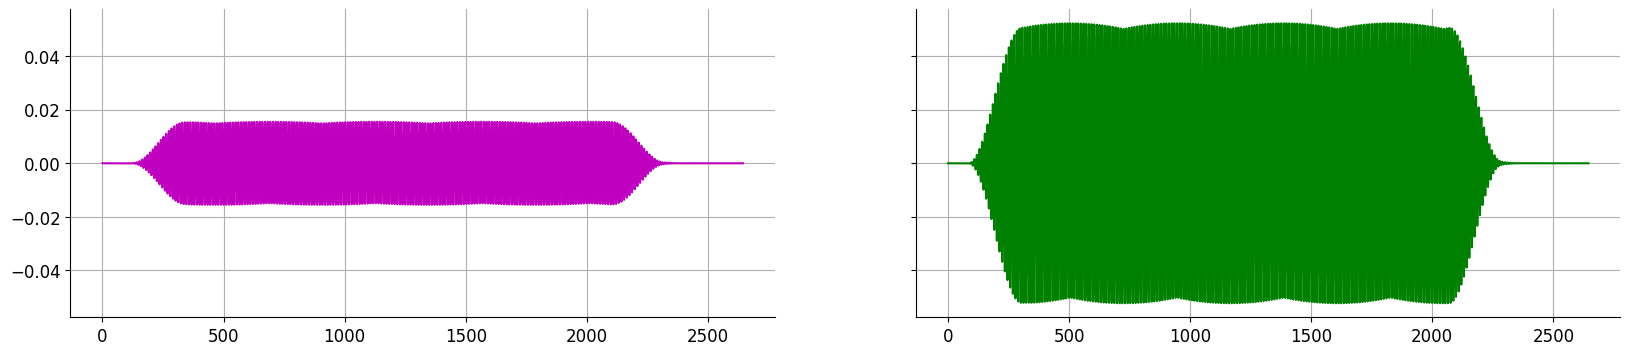

In [48]:
#1. Resample HRIRs
print("len hrir before resample:", len(left_ir))
if sound_fs != sofa_fs:
    print("sound_fs", sound_fs)
    print("hrir_fs", sofa_fs)
    # Compute new length after resampling
    N_old = left_ir.shape[0]
    N_new = int(round(N_old * (sound_fs / sofa_fs)))
    left_ir  = resample(left_ir,  N_new)
    right_ir = resample(right_ir, N_new)
print("len hrir after resample:", len(left_ir))

#2. Zero-pad
x = sound.sound.flatten()
times = np.arange(len(x)) / sound_fs * 1000  # in ms
N = len(x)
ir_len = max(len(left_ir), len(right_ir))
# nmax = next power of 2 >= (signal + ir_length)
nmax = max(N + ir_len, ir_len)
nmax = 2**int(np.ceil(np.log2(nmax)))
# Zero-pad HRIRs to nmax
Lpad = np.hstack([left_ir,  np.zeros(nmax - len(left_ir))])
Rpad = np.hstack([right_ir, np.zeros(nmax - len(right_ir))])
xpad = np.hstack([np.zeros(ir_len), x, np.zeros(nmax - ir_len - N)])
times = np.arange(Lpad.shape[0]) / sound_fs * 1000  # in ms

#3. FFT

L_fft = rfft(Lpad)
R_fft = rfft(Rpad)
X_fft = rfft(xpad)
# IMPORTANT: frequency axis must match nmax!
freqs = np.fft.rfftfreq(nmax, d=1/sound_fs)
# --- Convert to magnitude in dB ---
eps = 1e-12
L_mag = 20 * np.log10(np.abs(L_fft) + eps)
R_mag = 20 * np.log10(np.abs(R_fft) + eps)
X_mag = 20 * np.log10(np.abs(X_fft) + eps)

#4. Convolution in frequency domain
LX_mag = 20 * np.log10(np.abs(L_fft * X_fft) + eps)
RX_mag = 20 * np.log10(np.abs(R_fft * X_fft) + eps)

#5. Inverse FFT to get output sound
L_out = irfft(L_fft * X_fft).real
R_out = irfft(R_fft * X_fft).real
L_final = L_out[ir_len:ir_len + N]
R_final = R_out[ir_len:ir_len + N]

#6. Level of output sounds
from brian2hears import Sound
Sound(L_final, sound.sound.samplerate).level
Sound(R_final, sound.sound.samplerate).level
print("Left ear sound level (dB SPL):", Sound(L_final, sound.sound.samplerate).level)
print("Right ear sound level (dB SPL):", Sound(R_final, sound.sound.samplerate).level)
#check:
# L_rms = np.sqrt(np.mean(L_final**2))
# R_rms = np.sqrt(np.mean(R_final**2))
# ms_L_dB = 20.0 * np.log10(L_rms / 2e-5)
# ms_R_dB = 20.0 * np.log10(R_rms / 2e-5)
# print("Left ear sound level (dB SPL):", ms_L_dB)
# print("Right ear sound level (dB SPL):", ms_R_dB)

# --- Plot Padding---
fig, ax = plt.subplots(2,1, sharex=True)
ax[0].plot(times, Lpad, color='m')
ax[0].plot(times, Rpad, color='g')
ax[0].set_title(f'Padded HRTF IR')
ax[1].plot(times, xpad, color='b')
ax[1].set_xlabel("Time (ms)")
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.semilogx(freqs, L_mag, color='m', label="Left HRIR → HRTF")
ax.semilogx(freqs, R_mag, color='g', label="Right HRIR → HRTF")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("HRTF Magnitude Response (dB)")
ax.legend()
# --- Custom log-spaced ticks in Hz ---
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000  # kHz → Hz
ax.set_xscale('log')              # explicit, even if semilogx already does it
ax.set_xticks(xticks_hz)
ax.set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
ax.set_xlabel("Frequency (kHz)")
ax.set_xlim(200, 20000)


# Phase
L_phase = np.unwrap(np.angle(L_fft))
R_phase = np.unwrap(np.angle(R_fft))
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.semilogx(freqs, L_phase, color='m')
ax.semilogx(freqs, R_phase, color='g')
ax.set_ylabel("Phase (radians)")
ax.set_xlabel("Frequency (Hz)")
ax.set_title("HRTF Phase Response")


# --- Plot Input Sound Spectrum---
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.semilogx(freqs, X_mag, color='b')
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Input Sound Spectrum")
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000  # kHz → Hz
ax.set_xscale('log')              # explicit, even if semilogx already does it
ax.set_xticks(xticks_hz)
ax.set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
ax.set_xlabel("Frequency (kHz)")
ax.set_xlim(0, 20000)

# --- Plot Sounds Spectrum ---
fig, ax = plt.subplots(1,2, figsize=(20, 4), sharey=True)
ax[0].semilogx(freqs, LX_mag, color='m', label="Left HRIR → HRTF")
ax[1].semilogx(freqs, RX_mag, color='g', label="Right HRIR → HRTF")
for v in [200, 500, 1200, 4000, 16000]:
    ax[0].axvline(v, color='gray', linestyle='dashed')
    ax[1].axvline(v, color='gray', linestyle='dashed')
ax[0].set_ylabel("Magnitude (dB)")
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000  # kHz → Hz
for a in [0,1]:
    ax[a].set_xscale('log')              # explicit, even if semilogx already does it
    ax[a].set_xticks(xticks_hz)
    ax[a].set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
    ax[a].set_xlabel("Frequency (kHz)")
    ax[a].set_xlim(200, 20000)

# --- Plot Sounds Time ---
fig, ax = plt.subplots(1,2, figsize=(20,4), sharey=True)
ax[0].plot(L_final, color='m')
ax[1].plot(R_final, color='g')


['RIEC_hrir_subject_001.sofa', 'RIEC_hrir_subject_002.sofa', 'RIEC_hrir_subject_003.sofa', 'RIEC_hrir_subject_004.sofa', 'RIEC_hrir_subject_005.sofa', 'RIEC_hrir_subject_006.sofa', 'RIEC_hrir_subject_007.sofa', 'RIEC_hrir_subject_008.sofa', 'RIEC_hrir_subject_009.sofa', 'RIEC_hrir_subject_010.sofa']


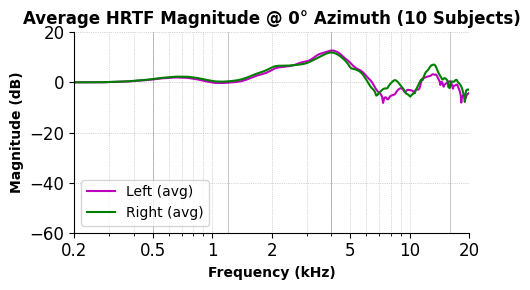

In [49]:
HRTF_DIR: str = "../data/SOFA/RIEC/"

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
TARGET_AZ = 0          # degrees
TARGET_EL = 0          # degrees
N_SUBJECTS = 10
EPS = 1e-12

# ------------------------------------------------------------
# Collect SOFA files (subjects)
# ------------------------------------------------------------
sofa_files = sorted(
    f for f in os.listdir(HRTF_DIR)
    if f.lower().endswith(".sofa")
)[:N_SUBJECTS]
print(sofa_files)
assert len(sofa_files) >= N_SUBJECTS, "Not enough SOFA files found"

L_mag_all = []
R_mag_all = []

# ------------------------------------------------------------
# Loop over subjects
# ------------------------------------------------------------
for fname in sofa_files:
    sofa_file = sofa.SOFAFile(str(HRTF_DIR + fname), "r")
    
    ir = sofa_file.getDataIR()                    # (M, R, N)
    positions = sofa_file.getSourcePositionValues()
    az = positions[:, 0]
    el = positions[:, 1]

    fs = float(np.array(sofa_file.getSamplingRate()).ravel()[0])

    # --- find closest measurement to (0°, 0°) ---
    az_conv = ANGLE_TO_SOFA[TARGET_AZ]
    dist = np.sqrt((az - az_conv)**2 + (el - TARGET_EL)**2)
    m_idx = int(np.argmin(dist))

    left_ir  = ir[m_idx, 0, :]
    right_ir = ir[m_idx, 1, :]

    # --- FFT ---
    L_fft = rfft(left_ir)
    R_fft = rfft(right_ir)

    # --- magnitude in dB ---
    L_mag = 20 * np.log10(np.abs(L_fft) + EPS)
    R_mag = 20 * np.log10(np.abs(R_fft) + EPS)

    L_mag_all.append(L_mag)
    R_mag_all.append(R_mag)

# ------------------------------------------------------------
# Stack and average across subjects
# ------------------------------------------------------------
L_mag_all = np.vstack(L_mag_all)
R_mag_all = np.vstack(R_mag_all)

L_mag_avg = np.mean(L_mag_all, axis=0)
R_mag_avg = np.mean(R_mag_all, axis=0)

# Frequency axis
n_fft = (L_mag_avg.size - 1) * 2
freqs = np.fft.rfftfreq(n_fft, d=1/fs)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 3))

ax.semilogx(freqs, L_mag_avg, color='m', label='Left (avg)')
ax.semilogx(freqs, R_mag_avg, color='g', label='Right (avg)')


ax.set_title(f"Average HRTF Magnitude @ 0° Azimuth ({N_SUBJECTS} Subjects)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlabel("Frequency (kHz)")
ax.set_xlim(200, 20000)
ax.set_ylim(-60, 20)

    
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000
ax.set_xticks(xticks_hz)
ax.set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
for v in [200, 500, 1200, 4000, 16000]:
    ax.axvline(v, color='k', linewidth=0.5, alpha=0.3)


ax.legend()
ax.grid(True, which='both', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()

## Many subjects

In [52]:
from utils.hrtf_utils import run_hrtf
from simulate.models.BrainstemModel.params import Parameters as params
from utils.anf_utils import ZI_COC_KEY, create_sound_key
from utils.cochlea_utils import ANGLES
from matplotlib import colors as mcolors
p = params()
print(p.cochlea[ZI_COC_KEY]['hrtf_params'])

{'subj_number': 0, 'cue_to_apply': 'HRTF', 'fixed_itd_us': 300}


2026-04-27 11:24:38,672 [DEBUG]  [run_hrtf] Starting for angle=0
2026-04-27 11:24:38,672 [DEBUG]  [run_hrtf] Applying FULL HRTF


(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Time (ms)', ylabel='Amplitude'>)

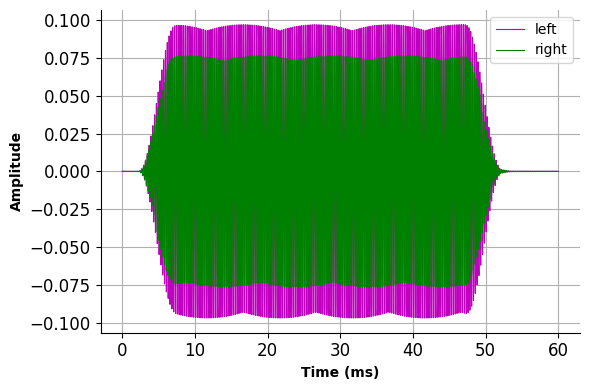

In [54]:
binaural, g = run_hrtf(sound, 0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
plot_sound(binaural)

2026-04-27 12:00:35,207 [DEBUG]  [run_hrtf] Starting for angle=-90
2026-04-27 12:00:35,207 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:35,213 [DEBUG]  [run_hrtf] Starting for angle=-75
2026-04-27 12:00:35,213 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:35,219 [DEBUG]  [run_hrtf] Starting for angle=-60
2026-04-27 12:00:35,220 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:35,226 [DEBUG]  [run_hrtf] Starting for angle=-45
2026-04-27 12:00:35,226 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:35,231 [DEBUG]  [run_hrtf] Starting for angle=-30
2026-04-27 12:00:35,231 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:35,238 [DEBUG]  [run_hrtf] Starting for angle=-15
2026-04-27 12:00:35,238 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:35,244 [DEBUG]  [run_hrtf] Starting for angle=0
2026-04-27 12:00:35,244 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:35,251 [DEBUG]  [run_hrtf] Starting for angle=15
2026-04-27 12:00:35,251 [D

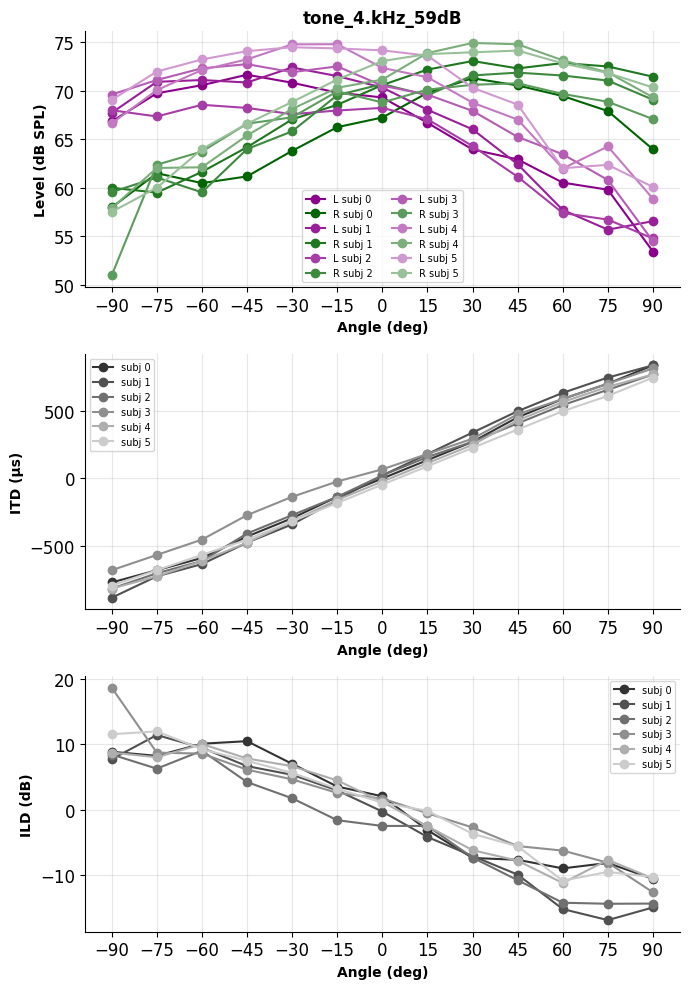

In [57]:
subjects = [0, 1, 2, 3, 4, 5]
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])
alphas = np.linspace(1.0, 0.4, len(subjects))
magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

# --- create figure ONCE, outside the loop ---
fig, ax = plt.subplots(3, 1, figsize=(7, 10))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    # --- reset per-subject accumulators inside the subject loop ---
    itds     = []
    ilds     = []
    l_levels = []
    r_levels = []

    for angle in ANGLES:
        left_ir, right_ir, sofa_fs = load_hrir(subj, ANGLE_TO_SOFA[angle]) 
        itd = estimate_itd_from_hrir(left_ir, right_ir, sound_fs)
        itds.append(itd * 1_000_000)
        binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_levels.append(binaural[:, 0].level)
        r_levels.append(binaural[:, 1].level)
        ild = l_levels[-1] - r_levels[-1]
        ilds.append(ild)

    # --- plot each subject's lines into the shared axes ---
    label_suffix = f"subj {subj}"
    ax[0].plot(ANGLES, l_levels, "o-", color=magenta_colors[s_idx],
               label=f"L {label_suffix}")
    ax[0].plot(ANGLES, r_levels, "o-", color=green_colors[s_idx],
               label=f"R {label_suffix}")
    ax[1].plot(ANGLES, itds,     "o-", color=plt.cm.gray(0.2 + 0.6 * s_idx / max(len(subjects)-1, 1)),
               label=label_suffix)
    ax[2].plot(ANGLES, ilds, "o-", color=plt.cm.gray(0.2 + 0.6 * s_idx / max(len(subjects)-1, 1)),
               label=label_suffix)

ax[0].set_title(create_sound_key(sound))
ax[0].set_ylabel("Level (dB SPL)")
ax[0].set_xlabel("Angle (deg)")
ax[0].set_xticks(ANGLES)
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=7, ncol=2)

ax[1].set_ylabel("ITD (μs)")
ax[1].set_xlabel("Angle (deg)")
ax[1].set_xticks(ANGLES)
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=7)

ax[2].set_ylabel("ILD (dB)")
ax[2].set_xlabel("Angle (deg)")
ax[2].set_xticks(ANGLES)
ax[2].grid(True, alpha=0.3)
ax[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

2026-04-27 12:00:36,071 [DEBUG]  [run_hrtf] Starting for angle=-90
2026-04-27 12:00:36,071 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:36,078 [DEBUG]  [run_hrtf] Starting for angle=-75
2026-04-27 12:00:36,078 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:36,085 [DEBUG]  [run_hrtf] Starting for angle=-60
2026-04-27 12:00:36,085 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:36,092 [DEBUG]  [run_hrtf] Starting for angle=-45
2026-04-27 12:00:36,092 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:36,103 [DEBUG]  [run_hrtf] Starting for angle=-30
2026-04-27 12:00:36,103 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:36,108 [DEBUG]  [run_hrtf] Starting for angle=-15
2026-04-27 12:00:36,108 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:36,114 [DEBUG]  [run_hrtf] Starting for angle=0
2026-04-27 12:00:36,114 [DEBUG]  [run_hrtf] Applying FULL HRTF
2026-04-27 12:00:36,119 [DEBUG]  [run_hrtf] Starting for angle=15
2026-04-27 12:00:36,119 [D

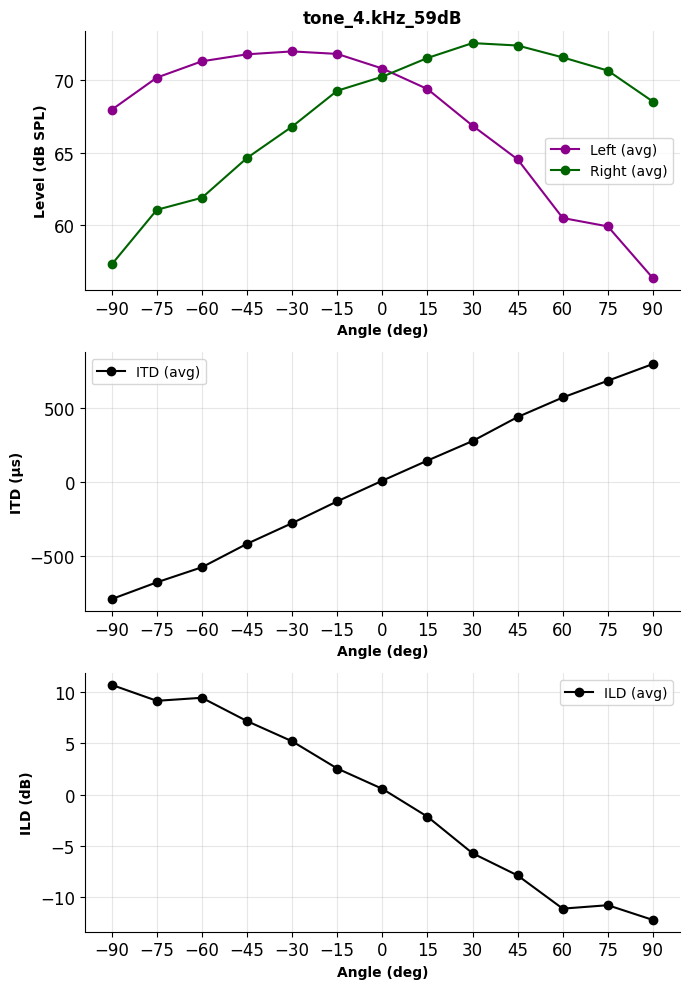

In [58]:
# --- accumulate across subjects ---
all_l_levels = []  # shape: (n_subjects, n_angles)
all_r_levels = []
all_itds     = []
all_ilds     = []

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    itds     = []
    ilds     = []
    l_levels = []
    r_levels = []

    for angle in ANGLES:
        left_ir, right_ir, sofa_fs = load_hrir(subj, ANGLE_TO_SOFA[angle])
        itd = estimate_itd_from_hrir(left_ir, right_ir, sound_fs)
        itds.append(itd * 1_000_000)
        binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_levels.append(binaural[:, 0].level)
        r_levels.append(binaural[:, 1].level)
        ild = l_levels[-1] - r_levels[-1]
        ilds.append(ild)

    all_l_levels.append(l_levels)
    all_r_levels.append(r_levels)
    all_itds.append(itds)
    all_ilds.append(ilds)

# --- compute means ---
mean_l   = np.mean(all_l_levels, axis=0)  # (n_angles,)
mean_r   = np.mean(all_r_levels, axis=0)
mean_itd = np.mean(all_itds,     axis=0)
mean_ild = np.mean(all_ilds,     axis=0)
# --- plot ---
fig, ax = plt.subplots(3, 1, figsize=(7, 10))
ax[0].set_title(create_sound_key(sound))

ax[0].plot(ANGLES, mean_l, "o-", color=base_magenta, label="Left (avg)")
ax[0].plot(ANGLES, mean_r, "o-", color=base_green,   label="Right (avg)")
ax[0].set_ylabel("Level (dB SPL)")
ax[0].set_xlabel("Angle (deg)")
ax[0].set_xticks(ANGLES)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(ANGLES, mean_itd, "o-", color='k', label="ITD (avg)")
ax[1].set_ylabel("ITD (μs)")
ax[1].set_xlabel("Angle (deg)")
ax[1].set_xticks(ANGLES)
ax[1].grid(True, alpha=0.3)
ax[1].legend()

ax[2].plot(ANGLES, mean_ild, "o-", color='k', label="ILD (avg)")
ax[2].set_ylabel("ILD (dB)")
ax[2].set_xlabel("Angle (deg)")
ax[2].set_xticks(ANGLES)
ax[2].grid(True, alpha=0.3)
ax[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
subjects = [0]
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])
alphas = np.linspace(1.0, 0.4, len(subjects))
magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

# --- create figure ONCE, outside the loop ---
fig, ax = plt.subplots(2, 1, figsize=(7, 10))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    # --- reset per-subject accumulators inside the subject loop ---
    ilds     = []

    for angle in ANGLES:
        binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_levels.append(binaural[:, 0].level)
        r_levels.append(binaural[:, 1].level)

        computed_ild = left_level - right_level
        print(f"Computed ILD: {computed_ild:.2f} dB")

    # --- plot each subject's lines into the shared axes ---
    label_suffix = f"subj {subj}"
    ax[0].plot(ANGLES, l_levels, "o-", color=magenta_colors[s_idx],
               label=f"L {label_suffix}")
    ax[0].plot(ANGLES, r_levels, "o-", color=green_colors[s_idx],
               label=f"R {label_suffix}")
    ax[1].plot(ANGLES, itds,     "o-", color=plt.cm.gray(0.2 + 0.6 * s_idx / max(len(subjects)-1, 1)),
               label=label_suffix)

ax[0].set_title(create_sound_key(sound))
ax[0].set_ylabel("Level (dB SPL)")
ax[0].set_xlabel("Angle (deg)")
ax[0].set_xticks(ANGLES)
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=7, ncol=2)

ax[1].set_ylabel("ITD (μs)")
ax[1].set_xlabel("Angle (deg)")
ax[1].set_xticks(ANGLES)
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [64]:
TIME_SIMULATION = 50
level = 60 * b2h.dB

inputs = [
    Tone(0.5 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=50 * b2.ms),
    Tone(1.2 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=50 * b2.ms),
    Tone(4 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=50 * b2.ms),
    Tone(16 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=50 * b2.ms),
    WhiteNoise(TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=50 * b2.ms),
]
inputs_2 = [Click(duration= TIME_SIMULATION * b2.ms, click_duration=1, level=80* b2h.dB),
            Click_Train(duration=TIME_SIMULATION * b2.ms, click_duration=0.05*b2.ms, level=80* b2h.dB, interval=5*b2.ms),]

2026-03-11 13:46:24,035 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:24,039 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:24,043 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:24,046 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:24,049 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0


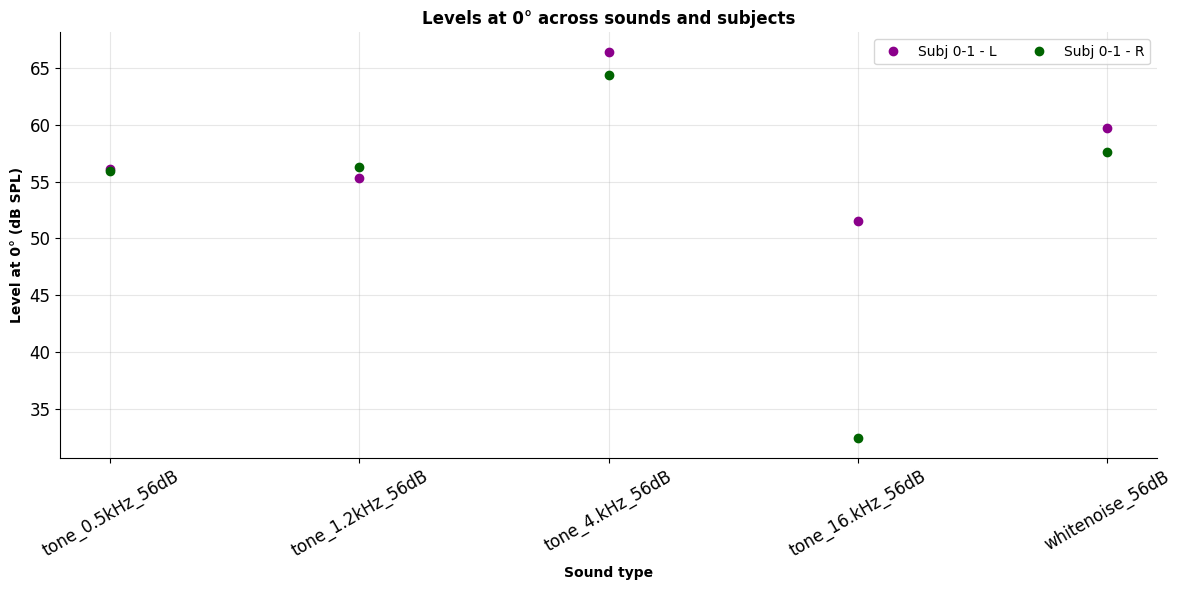

In [66]:
# pick the angle you want to isolate
ANGLE0 = 0
subjects = [0]#range(5)
# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

plt.figure(figsize=(12, 6))
plt.title(f"Levels at {ANGLE0}° across sounds and subjects")

sound_labels = [create_sound_key(s) for s in inputs]
x = np.arange(len(inputs))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    # plot for each subject: L solid, R dashed
    plt.plot(
        x, l_at_0, "o", 
        color=magenta_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - L" if s_idx == 0 else None
    )
    plt.plot(
        x, r_at_0, "o",
        color=green_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - R" if s_idx == 0 else None
    )

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


2026-03-11 13:46:24,839 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:24,843 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:24,847 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:24,865 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:24,869 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-03-11 13:46:24,886 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-03-11 13:46:24,890 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=3
2026-03-11 13:46:24,906 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=3
2026-03-11 13:46:24,910 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=4
2026-03-11 13:46:24,927 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=4


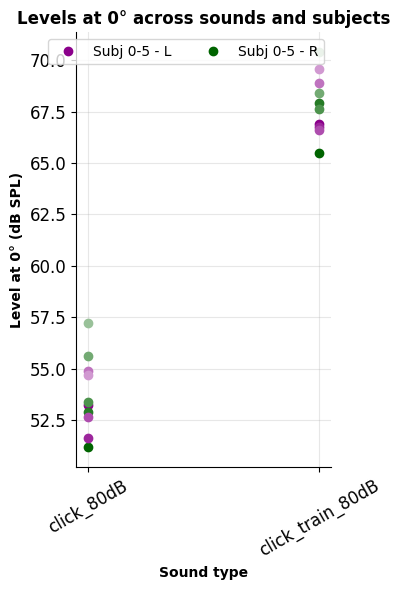

In [67]:
# pick the angle you want to isolate
ANGLE0 = 0
subjects = range(5)
# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

plt.figure(figsize=(4, 6))
plt.title(f"Levels at {ANGLE0}° across sounds and subjects")

sound_labels = [create_sound_key(s) for s in inputs_2]
x = np.arange(len(inputs_2))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs_2:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    # plot for each subject: L solid, R dashed
    plt.plot(
        x, l_at_0, "o", 
        color=magenta_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - L" if s_idx == 0 else None
    )
    plt.plot(
        x, r_at_0, "o",
        color=green_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - R" if s_idx == 0 else None
    )

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


2026-03-11 13:46:27,316 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:27,330 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:27,341 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:27,363 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:27,375 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:27,384 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:27,401 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:27,414 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:27,430 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:27,444 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:27,459 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-03-11 13:46:27,500 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-03-11 13:46:27,513 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2

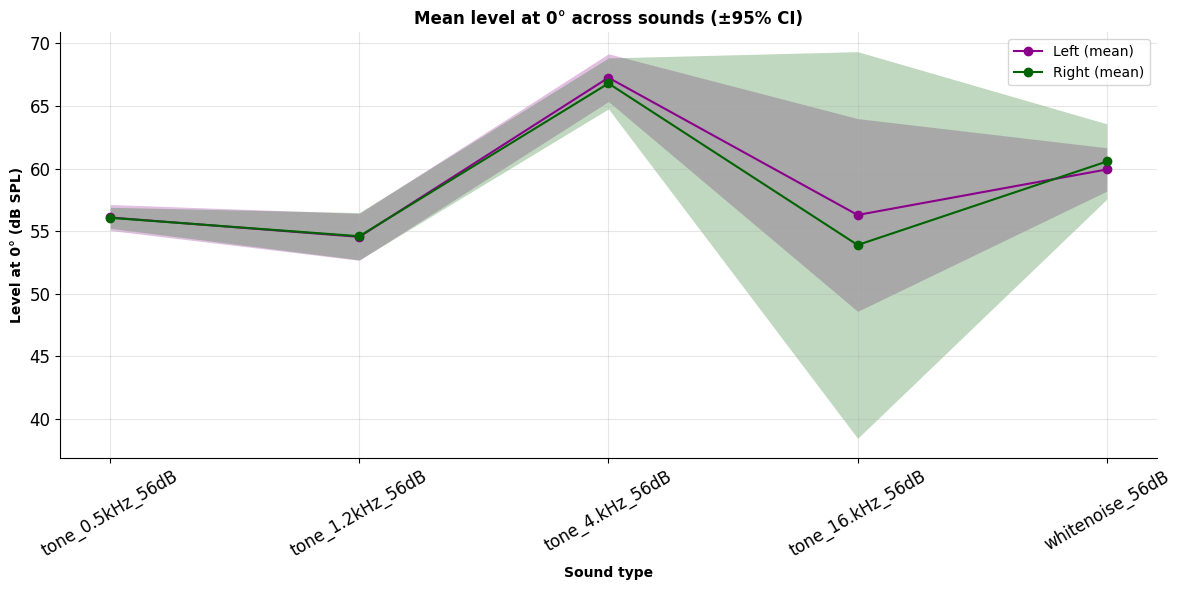

In [68]:
from scipy.stats import t

ANGLE0 = 0

plt.figure(figsize=(12, 6))
plt.title(f"Mean level at {ANGLE0}° across sounds (±95% CI)")

sound_labels = [create_sound_key(s) for s in inputs]
x = np.arange(len(inputs))

# containers: shape = (n_subjects, n_sounds)
L_all = []
R_all = []

for subj in subjects:
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    L_all.append(l_at_0)
    R_all.append(r_at_0)

L_all = np.array(L_all)  # (subjects, sounds)
R_all = np.array(R_all)

# --- statistics ---
n = len(subjects)
df = n - 1
tval = t.ppf(0.975, df)  # 95% CI

L_mean = L_all.mean(axis=0)
R_mean = R_all.mean(axis=0)

L_sem = L_all.std(axis=0, ddof=1) / np.sqrt(n)
R_sem = R_all.std(axis=0, ddof=1) / np.sqrt(n)

L_ci = tval * L_sem
R_ci = tval * R_sem

# --- plot ---
plt.plot(x, L_mean, "o-", color="darkmagenta", label="Left (mean)")
plt.plot(x, R_mean, "o-", color="darkgreen", label="Right (mean)")

plt.fill_between(
    x, L_mean - L_ci, L_mean + L_ci,
    color="darkmagenta", alpha=0.25, linewidth=0
)
plt.fill_between(
    x, R_mean - R_ci, R_mean + R_ci,
    color="darkgreen", alpha=0.25, linewidth=0
)

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


2026-03-11 13:46:28,271 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:28,277 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:28,282 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:28,288 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-03-11 13:46:28,292 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-03-11 13:46:28,306 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-03-11 13:46:28,312 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=3
2026-03-11 13:46:28,326 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=3
2026-03-11 13:46:28,330 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=4
2026-03-11 13:46:28,344 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=4


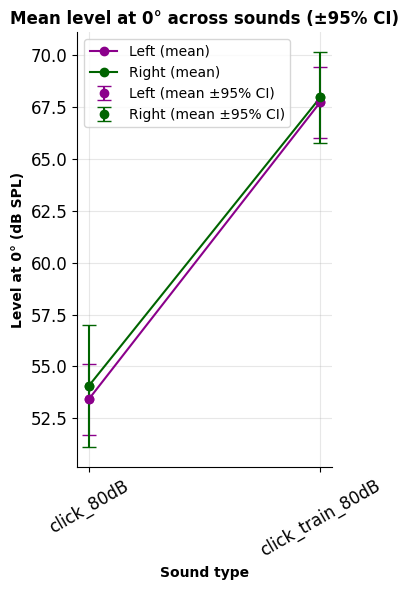

In [69]:
from scipy.stats import t

ANGLE0 = 0

plt.figure(figsize=(4, 6))
plt.title(f"Mean level at {ANGLE0}° across sounds (±95% CI)")

sound_labels = [create_sound_key(s) for s in inputs_2]
x = np.arange(len(inputs_2)) 
# containers: shape = (n_subjects, n_sounds)
L_all = []
R_all = []

for subj in subjects:
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs_2:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    L_all.append(l_at_0)
    R_all.append(r_at_0)

L_all = np.array(L_all)  # (subjects, sounds)
R_all = np.array(R_all)

# --- statistics ---
n = len(subjects)
df = n - 1
tval = t.ppf(0.975, df)  # 95% CI

L_mean = L_all.mean(axis=0)
R_mean = R_all.mean(axis=0)

L_sem = L_all.std(axis=0, ddof=1) / np.sqrt(n)
R_sem = R_all.std(axis=0, ddof=1) / np.sqrt(n)

L_ci = tval * L_sem
R_ci = tval * R_sem

# --- plot ---
plt.plot(x, L_mean, "o-", color="darkmagenta", label="Left (mean)")
plt.plot(x, R_mean, "o-", color="darkgreen", label="Right (mean)")

# single sound → use error bars
plt.errorbar(
    x, L_mean, yerr=L_ci,
    fmt="o", color="darkmagenta",
    capsize=5, label="Left (mean ±95% CI)"
)
plt.errorbar(
    x, R_mean, yerr=R_ci,
    fmt="o", color="darkgreen",
    capsize=5, label="Right (mean ±95% CI)"
)


plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


2026-03-11 13:46:29,003 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-11 13:46:29,007 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-11 13:46:29,011 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-11 13:46:29,017 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-03-11 13:46:29,022 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-03-11 13:46:29,028 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-03-11 13:46:29,031 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:29,034 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-03-11 13:46:29,037 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-03-11 13:46:29,041 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-03-11 13:46:29,044 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-03-11 13:46:29,047 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-03-11 13:46:29,051 [DEBUG]  [run_hrtf] Starting HRTF f

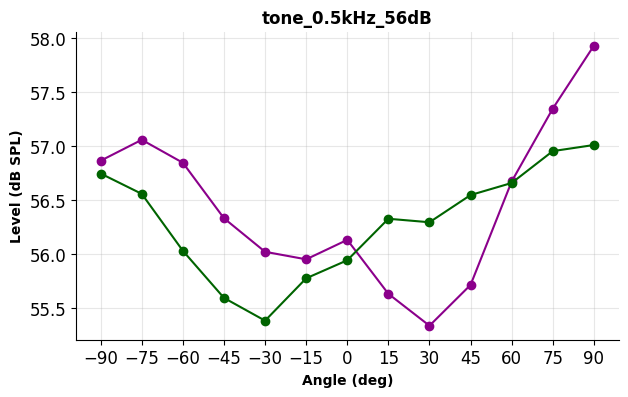

2026-03-11 13:46:29,097 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-11 13:46:29,101 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-11 13:46:29,105 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-11 13:46:29,109 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-03-11 13:46:29,112 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-03-11 13:46:29,116 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-03-11 13:46:29,118 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:29,122 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-03-11 13:46:29,125 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-03-11 13:46:29,128 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-03-11 13:46:29,131 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-03-11 13:46:29,135 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-03-11 13:46:29,138 [DEBUG]  [run_hrtf] Starting HRTF f

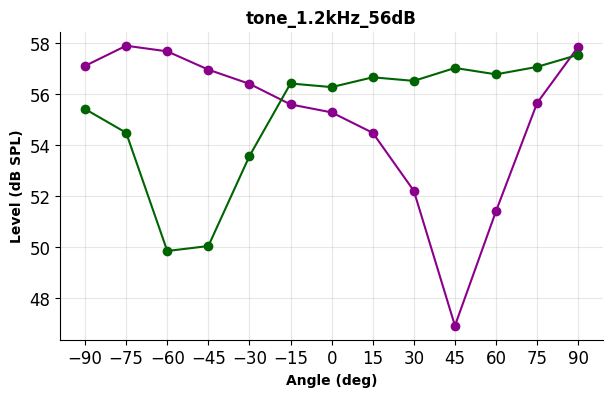

2026-03-11 13:46:29,184 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-11 13:46:29,190 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-11 13:46:29,194 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-11 13:46:29,200 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-03-11 13:46:29,204 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-03-11 13:46:29,210 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-03-11 13:46:29,214 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:29,218 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-03-11 13:46:29,222 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-03-11 13:46:29,226 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-03-11 13:46:29,230 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-03-11 13:46:29,233 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-03-11 13:46:29,236 [DEBUG]  [run_hrtf] Starting HRTF f

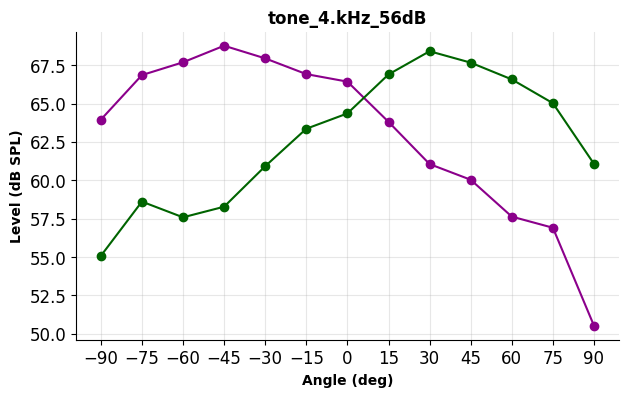

2026-03-11 13:46:29,286 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-11 13:46:29,291 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-11 13:46:29,294 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-11 13:46:29,297 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-03-11 13:46:29,301 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-03-11 13:46:29,304 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-03-11 13:46:29,308 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:29,311 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-03-11 13:46:29,314 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-03-11 13:46:29,318 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-03-11 13:46:29,321 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-03-11 13:46:29,324 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-03-11 13:46:29,327 [DEBUG]  [run_hrtf] Starting HRTF f

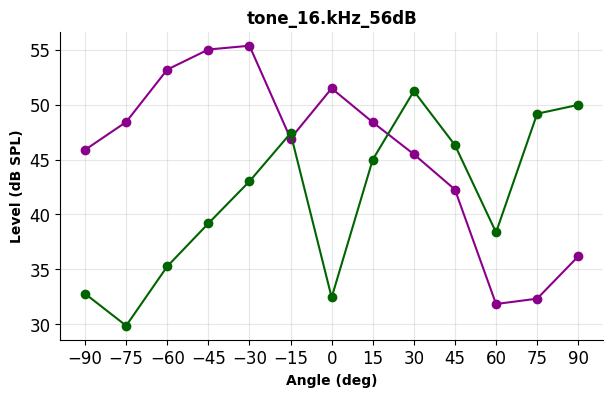

2026-03-11 13:46:29,372 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-11 13:46:29,377 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-11 13:46:29,380 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-11 13:46:29,384 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-03-11 13:46:29,388 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-03-11 13:46:29,391 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-03-11 13:46:29,394 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:29,397 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-03-11 13:46:29,400 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-03-11 13:46:29,404 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-03-11 13:46:29,407 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-03-11 13:46:29,410 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-03-11 13:46:29,415 [DEBUG]  [run_hrtf] Starting HRTF f

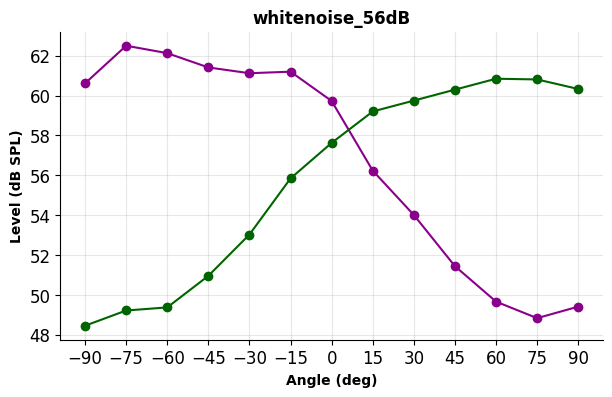

In [70]:
subjects = [0]
for sound in inputs:
    plt.figure(figsize=(7, 4))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested



    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o-",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    # legend: one entry for Left and one for Right is usually enough
    plt.show()


2026-03-11 13:46:30,082 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-11 13:46:30,089 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-11 13:46:30,093 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-11 13:46:30,097 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-03-11 13:46:30,101 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-03-11 13:46:30,104 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-03-11 13:46:30,108 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:30,111 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-03-11 13:46:30,115 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-03-11 13:46:30,118 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-03-11 13:46:30,122 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-03-11 13:46:30,125 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-03-11 13:46:30,128 [DEBUG]  [run_hrtf] Starting HRTF f

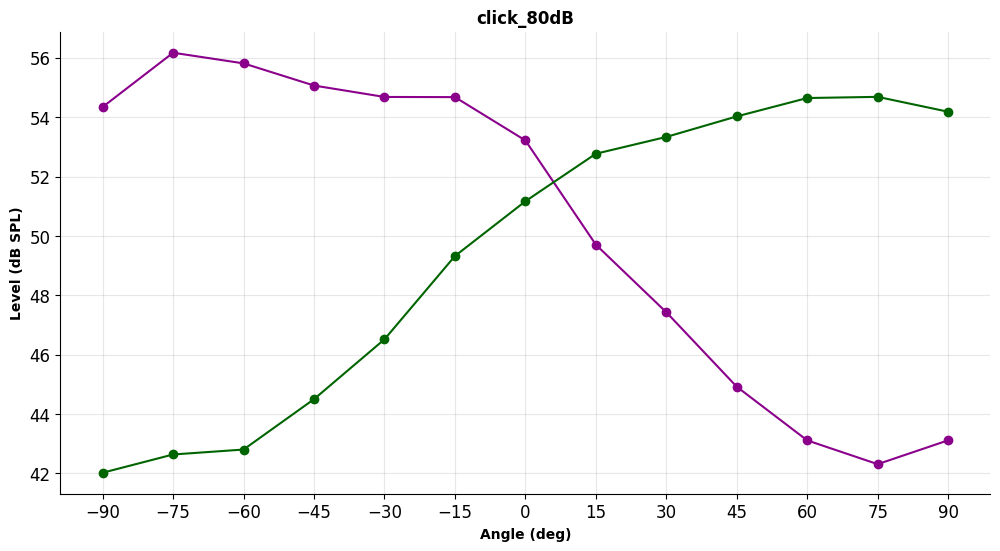

2026-03-11 13:46:30,180 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-11 13:46:30,184 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-11 13:46:30,189 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-11 13:46:30,192 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-03-11 13:46:30,195 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-03-11 13:46:30,199 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-03-11 13:46:30,201 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-03-11 13:46:30,205 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-03-11 13:46:30,208 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-03-11 13:46:30,211 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-03-11 13:46:30,214 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-03-11 13:46:30,217 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-03-11 13:46:30,220 [DEBUG]  [run_hrtf] Starting HRTF f

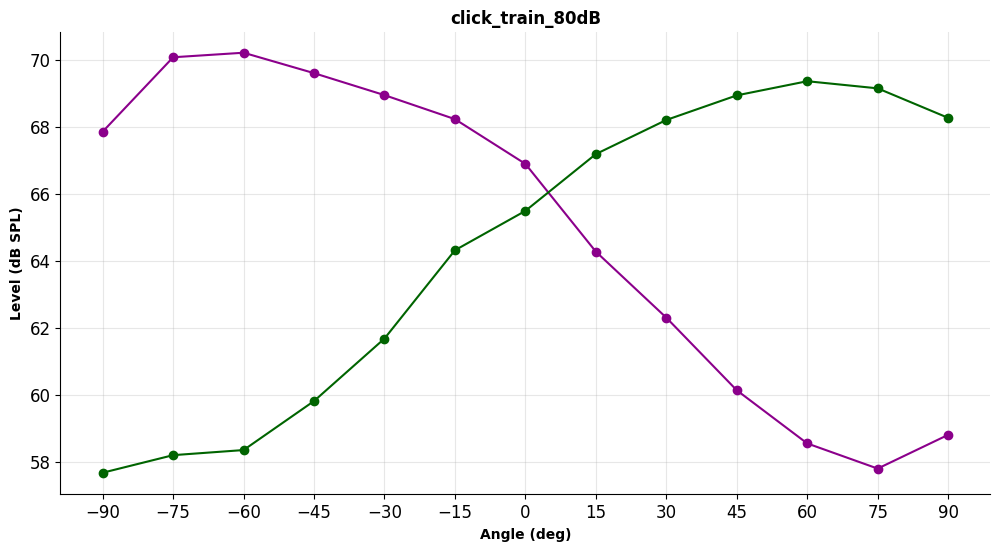

In [71]:
for sound in inputs_2:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o-",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    # legend: one entry for Left and one for Right is usually enough
    plt.show()


2026-03-03 10:47:18,221 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-03-03 10:47:18,257 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2026-03-03 10:47:18,297 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2026-03-03 10:47:18,351 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2026-03-03 10:47:18,403 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2026-03-03 10:47:18,462 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-03-03 10:47:18,491 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=1
2026-03-03 10:47:18,505 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=2
2026-03-03 10:47:18,516 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=3
2026-03-03 10:47:18,526 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=4
2026-03-03 10:47:18,560 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-03-03 10:47:18,576 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=1
2026-03-03 10:47:18,598 [DEBUG]  [run_hrtf] Starting

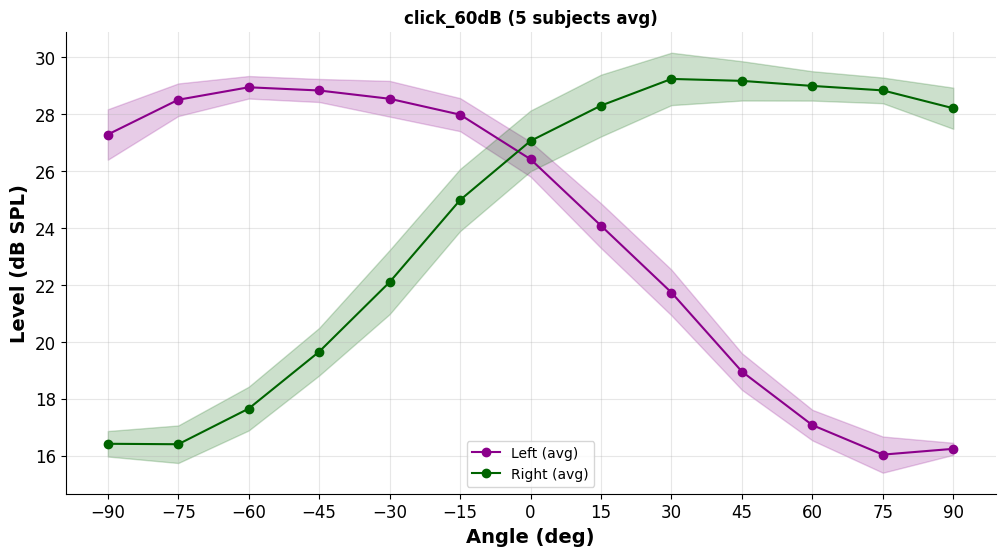

In [ ]:
from scipy.stats import sem

for sound in inputs_2:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(create_sound_key(sound) + f" ({len(subjects)} subjects avg)")


    # --- containers ---
    L_mean_all, R_mean_all = [], []
    L_sem_all,  R_sem_all  = [], []

    for angle in ANGLES:
        L_subj = []
        R_subj = []

        for subj in subjects:
            p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])

            L_subj.append(binaural[:, 0].level)
            R_subj.append(binaural[:, 1].level)

        L_subj = np.array(L_subj)
        R_subj = np.array(R_subj)

        # --- mean ---
        L_mean_all.append(L_subj.mean())
        R_mean_all.append(R_subj.mean())

        # --- SEM ---
        L_sem_all.append(sem(L_subj))
        R_sem_all.append(sem(R_subj))

    # convert to arrays
    L_mean_all = np.array(L_mean_all)
    R_mean_all = np.array(R_mean_all)

    L_sem_all = np.array(L_sem_all)
    R_sem_all = np.array(R_sem_all)

    # --- plotting means ---
    ax.plot(ANGLES, L_mean_all, "o-", color="darkmagenta", label="Left (avg)")
    ax.plot(ANGLES, R_mean_all, "o-", color="darkgreen", label="Right (avg)")

    # --- SEM shading ---
    ax.fill_between(
        ANGLES,
        L_mean_all - L_sem_all,
        L_mean_all + L_sem_all,
        color="darkmagenta",
        alpha=0.2
    )
    ax.fill_between(
        ANGLES,
        R_mean_all - R_sem_all,
        R_mean_all + R_sem_all,
        color="darkgreen",
        alpha=0.2
    )

    # --- cosmetics ---
    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Level (dB SPL)")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(ANGLES)
    ax.legend(loc="lower center")

    plt.show()
